# CIFAR-100-LT Exploratory Dataset Analysis

This notebook performs dataset-level visualization and analysis for the CIFAR-100 Long-Tailed dataset. It focuses on class frequency, head/medium/tail splits, train/test consistency, and example images without training any models.

In [2]:
import os
import json
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Section 1: Load Dataset

Load the CIFAR-100-LT dataset metadata from `class_counts.json` and summarize the long-tail class distribution.

In [4]:
DATA_DIR = Path("./data/CIFAR-100-LT")
fig_dir = Path("./outputs/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "class_counts.json", "r", encoding="utf-8") as f:
    class_counts = json.load(f)

# Support either flat dict of train counts or nested structure.
if isinstance(class_counts, dict) and all(isinstance(v, (int, float)) for v in class_counts.values()):
    df_counts = pd.DataFrame(
        [(cls, int(count)) for cls, count in class_counts.items()],
        columns=["class", "train_count"],
    )
else:
    raise ValueError("Unexpected format in class_counts.json")

# Sort descending by train count
class_count_df = df_counts.sort_values(by="train_count", ascending=False).reset_index(drop=True)

num_classes = class_count_df.shape[0]
max_count = class_count_df["train_count"].max()
min_count = class_count_df["train_count"].min()
imbalance_ratio = max_count / min_count if min_count > 0 else np.nan

print(f"Number of classes: {num_classes}")
print(f"Maximum samples per class: {max_count}")
print(f"Minimum samples per class: {min_count}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")

Number of classes: 100
Maximum samples per class: 500
Minimum samples per class: 5
Imbalance ratio (max/min): 100.00


## Section 2: Long-Tail Distribution

Visualize the class frequency distribution by sorting classes from most frequent to least frequent.

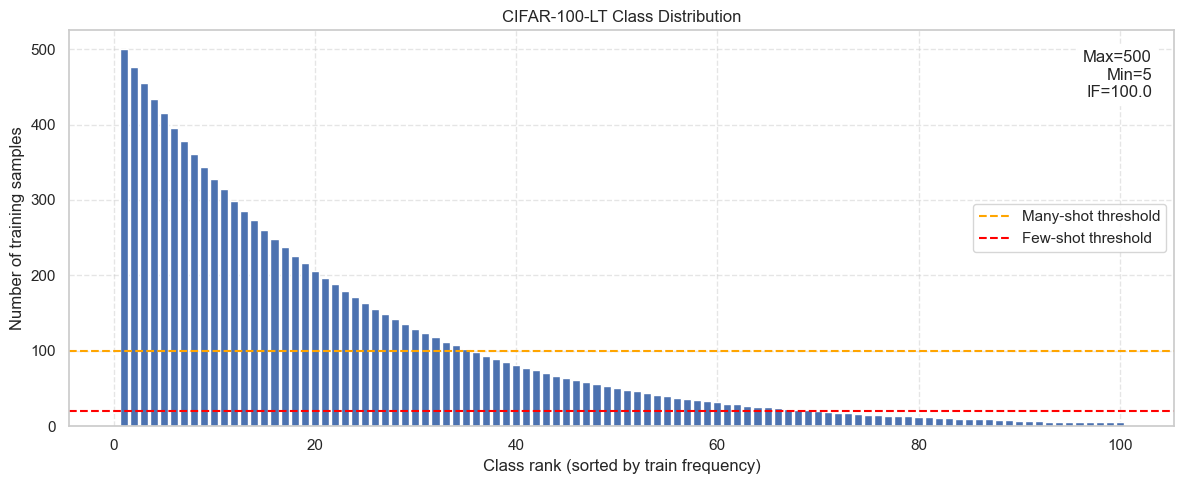

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(class_count_df.index + 1, class_count_df["train_count"], color="C0")
ax.axhline(100, color="orange", ls="--", label="Many-shot threshold")
ax.axhline(20, color="red", ls="--", label="Few-shot threshold")

ax.legend()
ax.text(
    0.98,
    0.95,
    f"Max={max_count}\nMin={min_count}\nIF={imbalance_ratio:.1f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white")
)
ax.set_title("CIFAR-100-LT Class Distribution")
ax.set_xlabel("Class rank (sorted by train frequency)")
ax.set_ylabel("Number of training samples")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
fig.savefig(fig_dir / "class_distribution.png", dpi=300)
plt.show()

## Section 3: Head / Medium / Tail Split

Split classes into head, medium, and tail groups to understand the long-tail structure.

In [6]:
conditions = [
    class_count_df["train_count"] > 100,
    class_count_df["train_count"].between(20, 100, inclusive="both"),
    class_count_df["train_count"] < 20,
]
choices = ["many-shot", "medium-shot", "few-shot"]
class_count_df["group"] = np.select(conditions, choices, default="other")

group_stats = (
    class_count_df.groupby("group")["train_count"]
    .agg(["count", "mean"])
    .rename(columns={"count": "num_classes", "mean": "avg_samples"})
    .reindex(["many-shot", "medium-shot", "few-shot"])
    .reset_index()
)

group_stats

,group,num_classes,avg_samples
0,many-shot,35,252.114286
1,medium-shot,35,49.085714
2,few-shot,30,10.166667


C:\Users\admin\AppData\Local\Temp\ipykernel_10224\1979783594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_stats, x="group", y="num_classes", palette="muted", width=0.5, ax=ax)


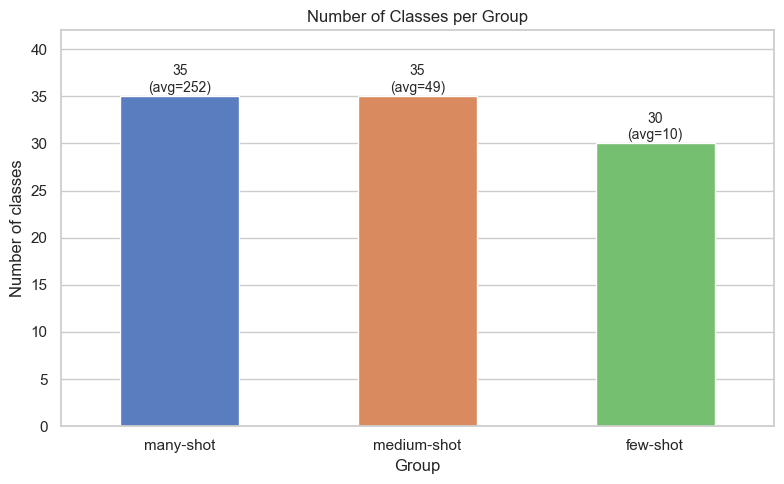

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=group_stats, x="group", y="num_classes", palette="muted", width=0.5, ax=ax)
ax.set_title("Number of Classes per Group")
ax.set_xlabel("Group")
ax.set_ylabel("Number of classes")
ax.margins(y=0.2)
for i, p in enumerate(ax.patches):
    height = p.get_height()
    avg_samples = group_stats.iloc[i]["avg_samples"]
    ax.text(
        p.get_x() + p.get_width()/2,
        height + 0.5,
        f"{int(height)}\n(avg={avg_samples:.0f})",
        ha="center",
        fontsize=10
    )
plt.tight_layout()
fig.savefig(fig_dir / "group_counts.png", dpi=300)
plt.show()

## Section 4: Class Frequency Statistics

Compute descriptive statistics for the per-class training sample counts.

In [8]:
stats = class_count_df["train_count"].agg(["mean", "median", "std"]).rename({"mean": "mean_count", "median": "median_count", "std": "std_count"})
stats_table = pd.DataFrame(stats).T
stats_table

,mean_count,median_count,std_count
train_count,108.47,49.5,128.211903


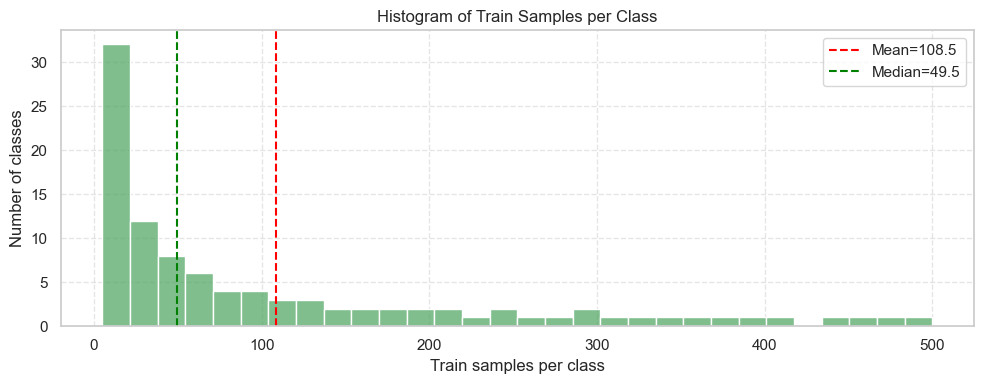

In [35]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(class_count_df["train_count"], bins=30, kde=False, color="C2", ax=ax)
ax.set_title("Histogram of Train Samples per Class")
ax.set_xlabel("Train samples per class")
ax.set_ylabel("Number of classes")
mean_count = stats_table.loc["train_count", "mean_count"]
median_count = stats_table.loc["train_count", "median_count"]
ax.axvline(mean_count, color="red", ls="--", label=f"Mean={mean_count:.1f}")
ax.axvline(median_count, color="green", ls="--", label=f"Median={median_count:.1f}")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
fig.savefig(fig_dir / "class_count_histogram.png", dpi=300)
plt.show()

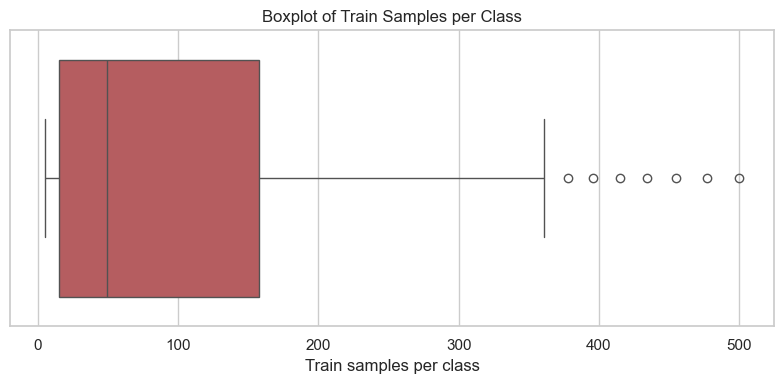

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x=class_count_df["train_count"], color="C3", ax=ax)
ax.set_title("Boxplot of Train Samples per Class")
ax.set_xlabel("Train samples per class")
plt.tight_layout()
fig.savefig(fig_dir / "class_count_boxplot.png", dpi=300)
plt.show()

## Section 5: Example Images

Show example images from the most frequent head classes and the least frequent tail classes to illustrate dataset diversity.

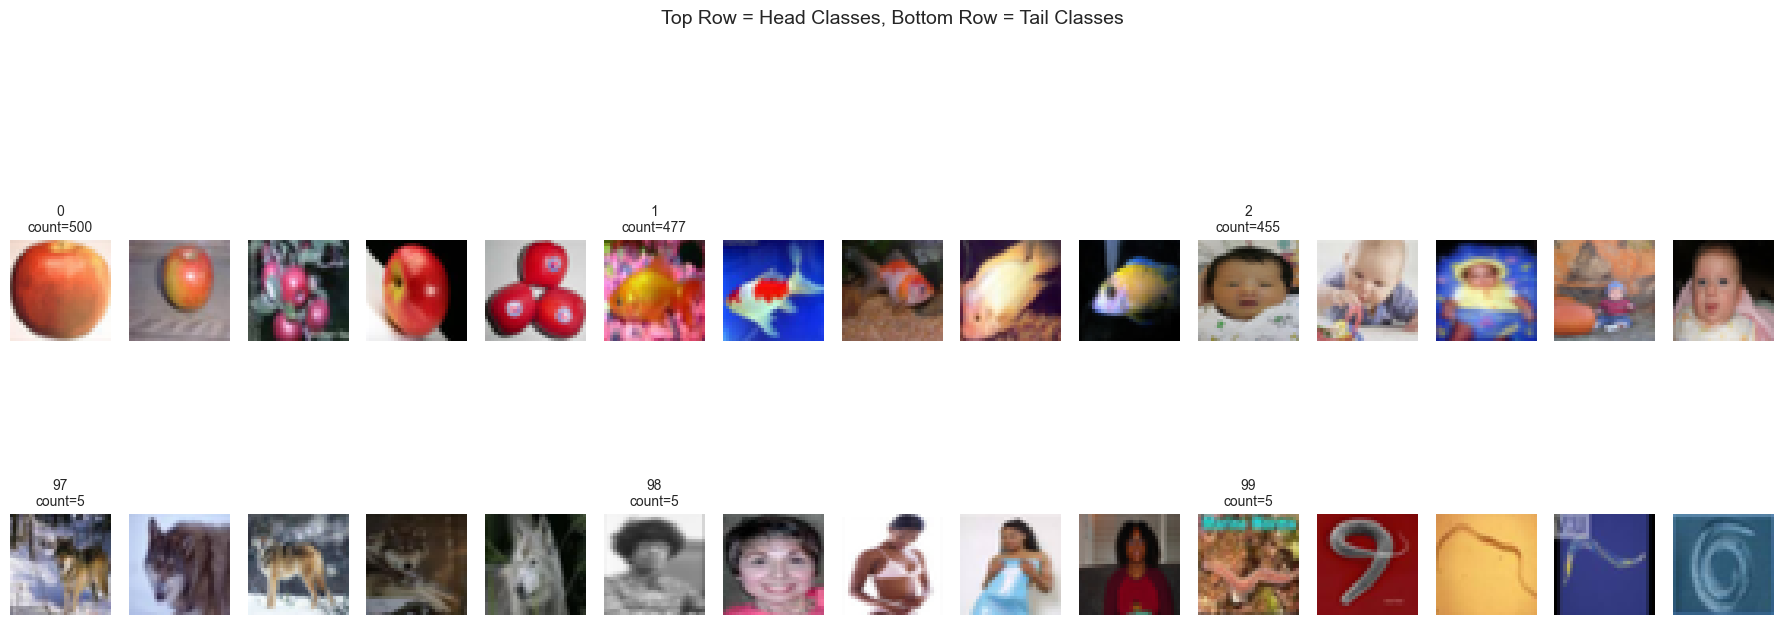

In [13]:
train_dir = DATA_DIR / "train"

top_classes = class_count_df.head(3)["class"].tolist()
bottom_classes = class_count_df.tail(3)["class"].tolist()
selected_classes = top_classes + bottom_classes

images_per_class = 5
fig, axes = plt.subplots(2, images_per_class * 3, figsize=(18, 8))

for row_idx, class_name in enumerate([top_classes, bottom_classes]):
    for col_idx, cls in enumerate(class_name):
        cls_idx = '0'*(3 - len(str(cls))) + str(cls)  # Zero-pad class index to 2 digits
        class_path = train_dir / f'class_{cls_idx}'
        images = sorted([p for p in class_path.iterdir() if p.is_file()])
        if len(images) == 0:
            continue
        selected_images = random.sample(images, min(images_per_class, len(images)))
        for sample_idx, image_path in enumerate(selected_images):
            ax = axes[row_idx, col_idx * images_per_class + sample_idx]
            img = Image.open(image_path)
            ax.imshow(img)
            ax.axis("off")
            if sample_idx == 0:
                count = class_count_df.loc[class_count_df["class"] == cls, "train_count"].iloc[0]
                row_label = "Head" if row_idx == 0 else "Tail"
                ax.set_title(f"{cls}\ncount={count}", fontsize=10)

fig.suptitle("Top Row = Head Classes, Bottom Row = Tail Classes", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(fig_dir / "head_vs_tail_examples.png", dpi=300)
plt.show()

## Section 6: Train/Test Consistency

Compare the number of images per class in the training and test splits.

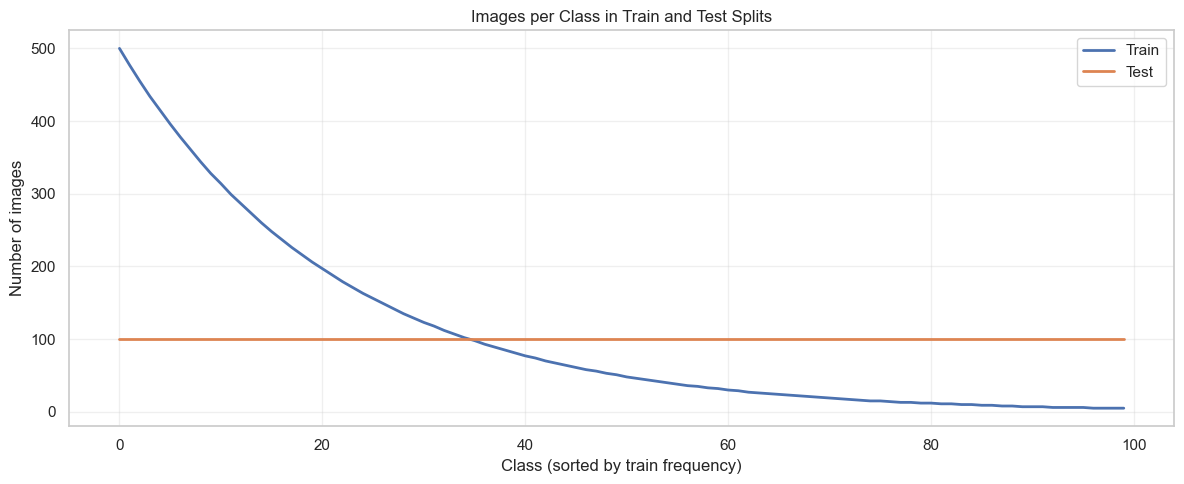

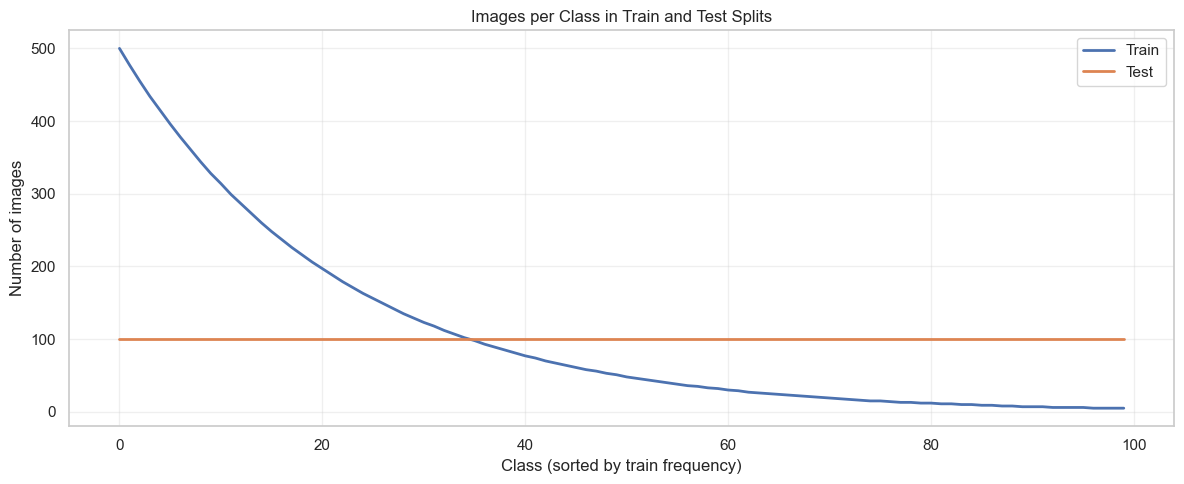

In [40]:
test_dir = DATA_DIR / "test"

train_counts = {}
test_counts = {}
for cls in sorted({p.name for p in train_dir.iterdir() if p.is_dir()}):
    class_path = train_dir / cls
    train_counts[cls] = len([p for p in class_path.iterdir() if p.is_file()])
for cls in sorted({p.name for p in test_dir.iterdir() if p.is_dir()}):
    class_path = test_dir / cls
    test_counts[cls] = len([p for p in class_path.iterdir() if p.is_file()])

consistency_df = pd.DataFrame(
    [(cls, train_counts.get(cls, 0), test_counts.get(cls, 0)) for cls in sorted(set(train_counts) | set(test_counts))],
    columns=["class", "train_count", "test_count"],
)

fig, ax = plt.subplots(figsize=(12, 5))

sorted_df = consistency_df.sort_values(
    "train_count",
    ascending=False
).reset_index(drop=True)

ax.plot(
    sorted_df.index,
    sorted_df["train_count"],
    label="Train",
    linewidth=2
)

ax.plot(
    sorted_df.index,
    sorted_df["test_count"],
    label="Test",
    linewidth=2
)

ax.set_title("Images per Class in Train and Test Splits")
ax.set_xlabel("Class (sorted by train frequency)")
ax.set_ylabel("Number of images")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(fig_dir / "train_test_scatter.png", dpi=300)
plt.show()

## Section 7: Summary Table

Create a summary table of dataset metrics and save the results as CSV.

In [44]:
summary_data = {
    "Metric": [
        "Number of Classes",
        "Total Train Images",
        "Total Test Images",
        "Max Class Size",
        "Min Class Size",
        "Mean Class Size",
        "Median Class Size",
        "Imbalance Ratio",
        "Many Classes",
        "Medium Classes",
        "Few Classes",
    ],
    "Value": [
        num_classes,
        class_count_df["train_count"].sum(),
        consistency_df["test_count"].sum(),
        int(max_count),
        int(min_count),
        float(stats_table.loc["train_count", "mean_count"]),
        float(stats_table.loc["train_count", "median_count"]),
        float(imbalance_ratio),
        int(group_stats.loc[group_stats["group"] == "many-shot", "num_classes"].iloc[0]),
        int(group_stats.loc[group_stats["group"] == "medium-shot", "num_classes"].iloc[0]),
        int(group_stats.loc[group_stats["group"] == "few-shot", "num_classes"].iloc[0]),
    ],
}
summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(Path("./outputs") / "summary.csv", index=False)
summary_df

,Metric,Value
0,Number of Classes,100.00
1,Total Train Images,10847.00
2,Total Test Images,10000.00
3,Max Class Size,500.00
4,Min Class Size,5.00
5,Mean Class Size,108.47
6,Median Class Size,49.50
7,Imbalance Ratio,100.00
8,Many Classes,35.00
9,Medium Classes,35.00
